In [1]:
import utils_FaIR_JAX
import utils_inverse
import matplotlib.pyplot as plt
import jax

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for N<sub>2</sub>O
Spatial invariance as future work - requires a fully differentiable model. Use Maren's test cases as examples for other targets to optimize over.

## 1. Verify LSTM framework and generate baseline emulator

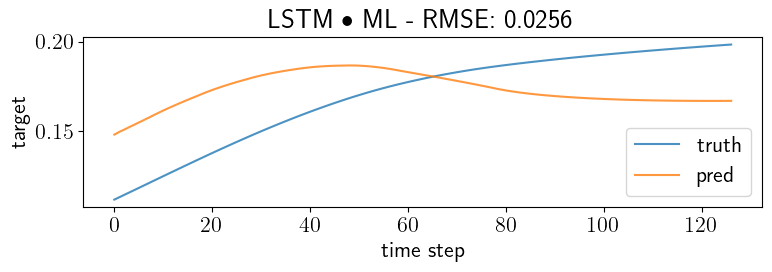

||grad BC||: 0.0
||grad CH4||: 0.0
||grad CO2||: 0.0
||grad N2O||: 2.1995383576722816e-06
||grad Sulfur||: 0.0


In [2]:
agents = ['N2O']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 3
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

test_scen = 'historical'
utils_inverse.test_get_grad(test_scen, params0, emis_dict_train_JAX, train_data, test_data, active=("N2O"))

## 2. Optimize N<sub>2</sub>O emissions time series used in training

### 2a. Train baseline emulator on ScenarioMIP tier 1

In [3]:
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True)
emis_dict_all_JAX = emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "All": emis_dict_all_JAX
}

In [4]:
paramsK_base, baseline_results, baseline_preds, ground_truth = utils_inverse.evaluate_baseline_over_multiple_tests(
    emis_dict_train=emis_dict_tier1_JAX,
    test_sets=test_sets,
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden=32,
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

import pickle
path = 'checkpoints/n2o/baseline_n2o_only.pkl'

with open(path, "wb") as f:
    pickle.dump(baseline_results, f)

for test_set in baseline_results:
    per_scen = baseline_results[test_set]
    mean_err = baseline_results[test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.1275
  historical                      0.2608
  H-ext                           0.0528
  M                               0.1289
  ML                              0.1289
  L                               0.1071
  VLLO-ext                        0.1084
  VLHO                            0.1055

Tier 2 mean scaled RMSE: 0.1281
  historical                      0.2608
  H-ext-OS                        0.0528
  M-ext                           0.1189
  ML-ext                          0.1189
  L-ext                           0.1089
  VLHO-ext                        0.1084

DECK mean scaled RMSE: 0.3122
  abrupt-4xN2O                    0.4097
  1pctN2O                         0.2147

CS3 mean scaled RMSE: 0.1863
  AA                              0.1260
  CT                              0.1102
  historical                      0.3226

All mean scaled RMSE: 0.1476
  historical                      0.3226
  H-ext                           0.0590
  M                    

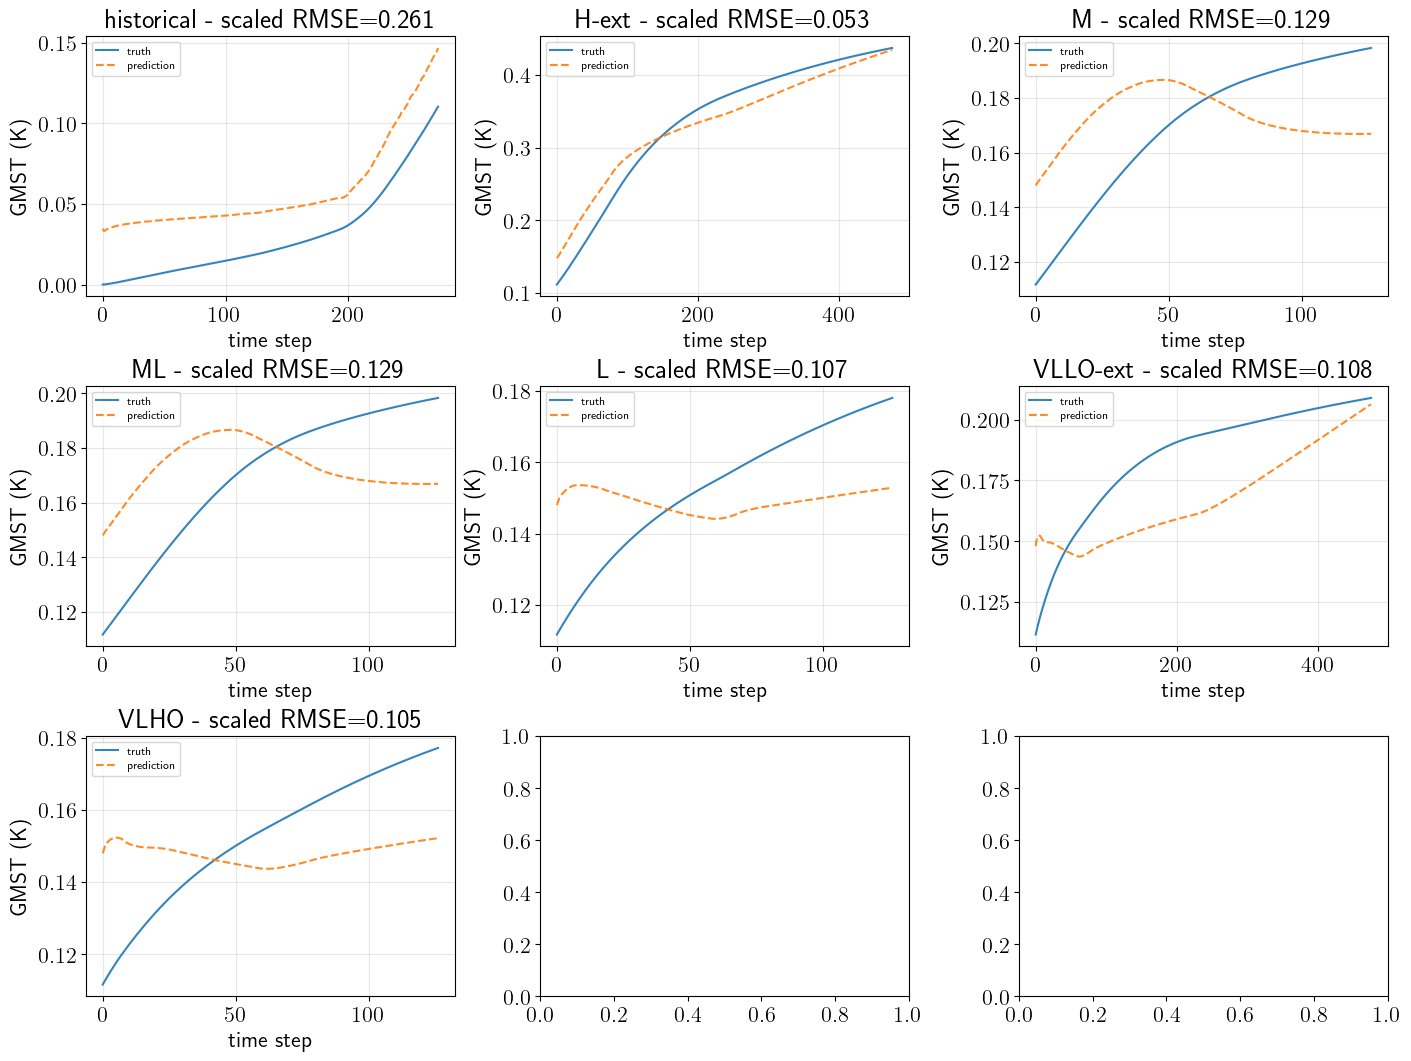

In [5]:
import numpy as np
test_set = 'Tier 1'
N_scens = len(baseline_results[test_set])
rows = int(np.ceil(N_scens / 3))
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5*rows), constrained_layout=True)
axes = axes.ravel()

for i, scen in enumerate(baseline_results[test_set]):
    if scen == 'mean':
        continue
    ax = axes[i]
    ax.plot(ground_truth[test_set][scen],  label="truth", alpha=0.9)
    ax.plot(baseline_preds[test_set][scen],  label="prediction", ls="--", alpha=0.9)
    ax.set_title(f"{scen} - scaled RMSE={baseline_results[test_set][scen]:.3f}")
    ax.set_xlabel("time step")
    ax.set_ylabel("GMST (K)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

### 2b. Optimize for H-ext, starting from H-ext initial condition (sanity check)

In [506]:
emis_dict_valid = {}
#emis_dict_valid['H-ext'] = jnp.concat([emis_dict_train_JAX['historical'].copy(), emis_dict_train_JAX['H-ext'].copy()], axis=1)
emis_dict_valid['H-ext'] = emis_dict_train_JAX['H-ext'].copy()
emis_dict_valid['historical'] = emis_dict_train_JAX['historical'].copy()

results_CO2_trivial = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=2,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path="checkpoints/co2/inverse_H-ext_co2_only.pkl",
    checkpoint_every=5,
    resume_if_exists=False,
    save_preds=True,
    preds_every=1,
    save_preds_in_ckpt=True,
    agents=("CO2","N2O"),
    active_agents=("CO2",),
    init_spec=emis_dict_valid['H-ext'],
    inactive_mode="zeros",
    T=477,
)

No checkpoint found, starting fresh...


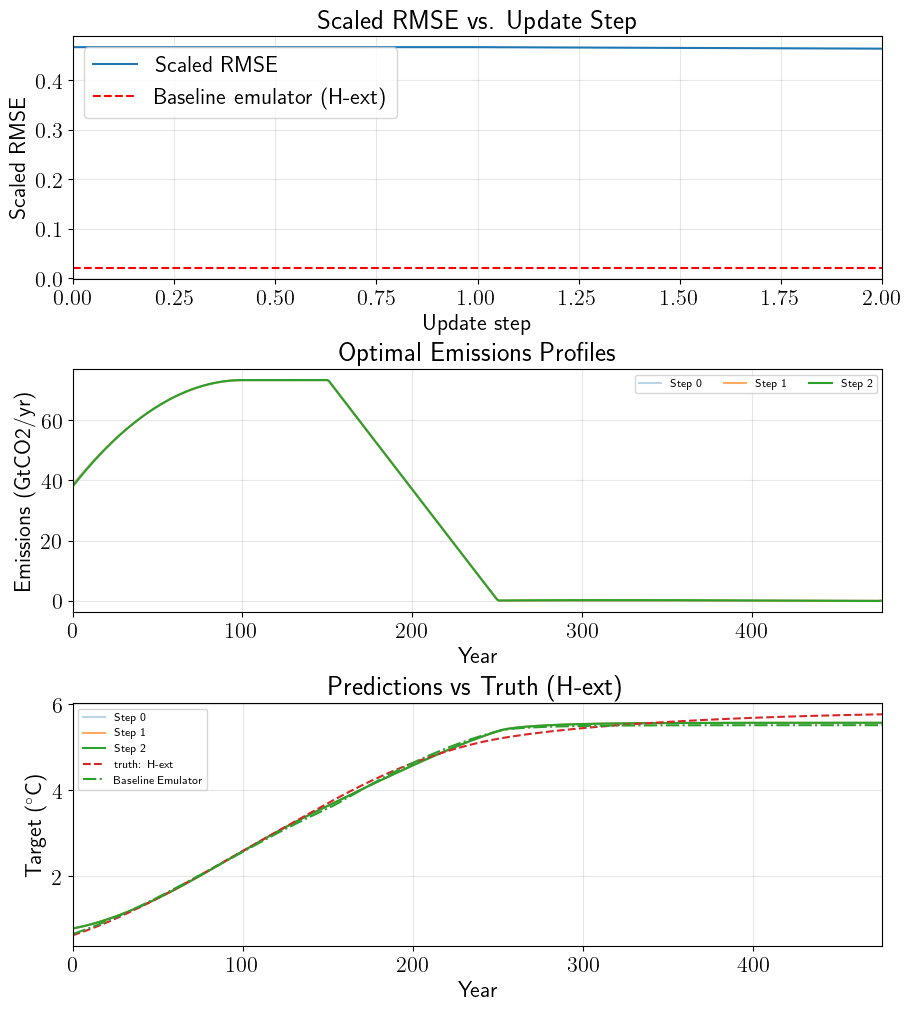

In [507]:
predict_plot = 'H-ext'
utils_inverse.plot_inverse_results(
    results_CO2_trivial,
    baseline_results['Tier 1'][predict_plot],
    active_agents=('CO2',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

### 2c. Optimize training data for predictive skill over ScenarioMIP tier 1, starting from constant, ramp, and Gaussian ICs

In [4]:
emis_dicts_valid = [(emis_dict_tier1_JAX.copy(), 'tier1'),
                    (emis_dict_tier2_JAX.copy(), 'tier2'),
                    (emis_dict_DECK_JAX.copy(), 'DECK'),
                    (emis_dict_CS3_JAX.copy(), 'CS3'),
                    (emis_dict_all_JAX.copy(), 'all')]
IC = 'constant'

for emis_dict, group in emis_dicts_valid:
    print(f'Optimizing over {group}')
    results_N2O_constant = utils_inverse.optimize_emissions_inverse(
        emis_dict=emis_dict,
        params0=params0,
        num_updates=1000,
        step_size=1e3,
        momentum=0.9,
        nesterov=True,
        K_inner=400,
        lr_inner=5e-2,
        wd_inner=1e-2,
        checkpoint_path=f"checkpoints/n2o/inverse_{IC}_{group}_n2o_only.pkl",
        checkpoint_every=50,
        resume_if_exists=True,
        preds_every=50,
        active_agents=("N2O",),
        init_spec=IC,
        inactive_mode="zeros",
        T=751,
        n_nonneg_prefix=0,
    )

Optimizing over tier1
Resuming from checkpoint...
Optimizing over tier2
Resuming from checkpoint...
Optimizing over DECK
Resuming from checkpoint...
Optimizing over CS3
Resuming from checkpoint...
Optimizing over all
Resuming from checkpoint...


In [52]:
emis_dict_valid = emis_dict_tier1_JAX.copy()
IC = 'constant'

results_N2O_tier1_constant = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_tier1_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
    n_nonneg_prefix=0,
)

Found 200 updates in checkpoint, starting from here...


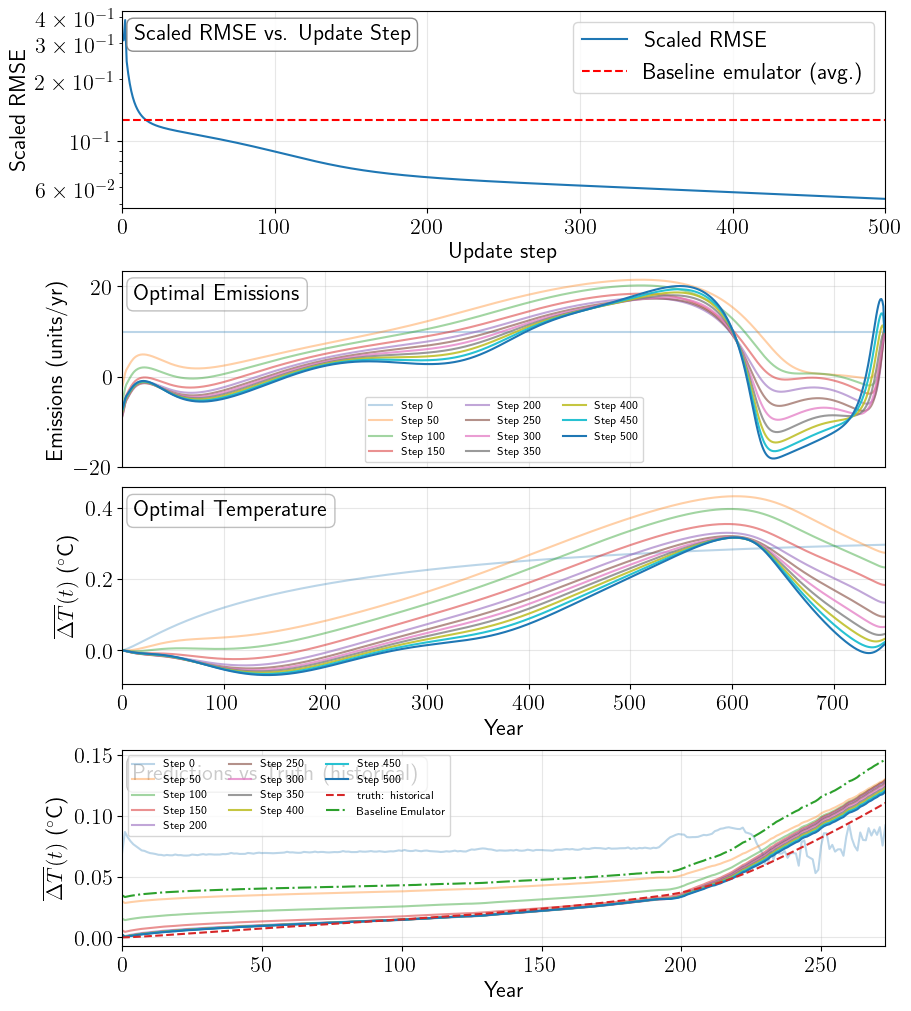

In [53]:
predict_plot = 'historical'
utils_inverse.plot_inverse_results(
    results_N2O_tier1_constant,
    baseline_results['Tier 1']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

In [63]:
emis_dict_valid = emis_dict_tier1_JAX.copy()
IC = 'constant'
targets = ['tier1','tier2','DECK','all']

for i, emis_dict_valid in enumerate([emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_calib_JAX]):
  t = targets[i]
  print(f'Optimizing for {t}...')
  for IC in ['constant','ramp','gaussian']:
    print(f'\t IC = {IC}')
    results_N2O = utils_inverse.optimize_emissions_inverse(
        emis_dict=emis_dict_valid,
        params0=params0,
        num_updates=300,
        step_size=1e3,
        momentum=0.9,
        nesterov=True,
        K_inner=400,
        lr_inner=5e-2,
        wd_inner=1e-2,
        checkpoint_path=f"checkpoints/n2o/inverse_{IC}_{t}_n2o_only.pkl",
        checkpoint_every=5,
        resume_if_exists=True,
        preds_every=1,
        active_agents=("N2O",),
        init_spec=IC,
        inactive_mode="zeros",
        T=751,
        n_nonneg_prefix=0,
    )

Optimizing for tier1...
	 IC = constant
Found 500 updates in checkpoint, starting from here...
	 IC = ramp
Found 300 updates in checkpoint, starting from here...
	 IC = gaussian
No checkpoint found, starting fresh...
Optimizing for tier2...
	 IC = constant
No checkpoint found, starting fresh...
	 IC = ramp
No checkpoint found, starting fresh...
	 IC = gaussian
No checkpoint found, starting fresh...
Optimizing for DECK...
	 IC = constant
No checkpoint found, starting fresh...
	 IC = ramp
No checkpoint found, starting fresh...
	 IC = gaussian
No checkpoint found, starting fresh...
Optimizing for all...
	 IC = constant
No checkpoint found, starting fresh...
	 IC = ramp
No checkpoint found, starting fresh...
	 IC = gaussian
No checkpoint found, starting fresh...


In [61]:
emis_dict_valid = emis_dict_tier1_JAX.copy()
IC = 'ramp'

results_N2O_tier1_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_tier1_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
    n_nonneg_prefix=0,
)

Found 295 updates in checkpoint, starting from here...


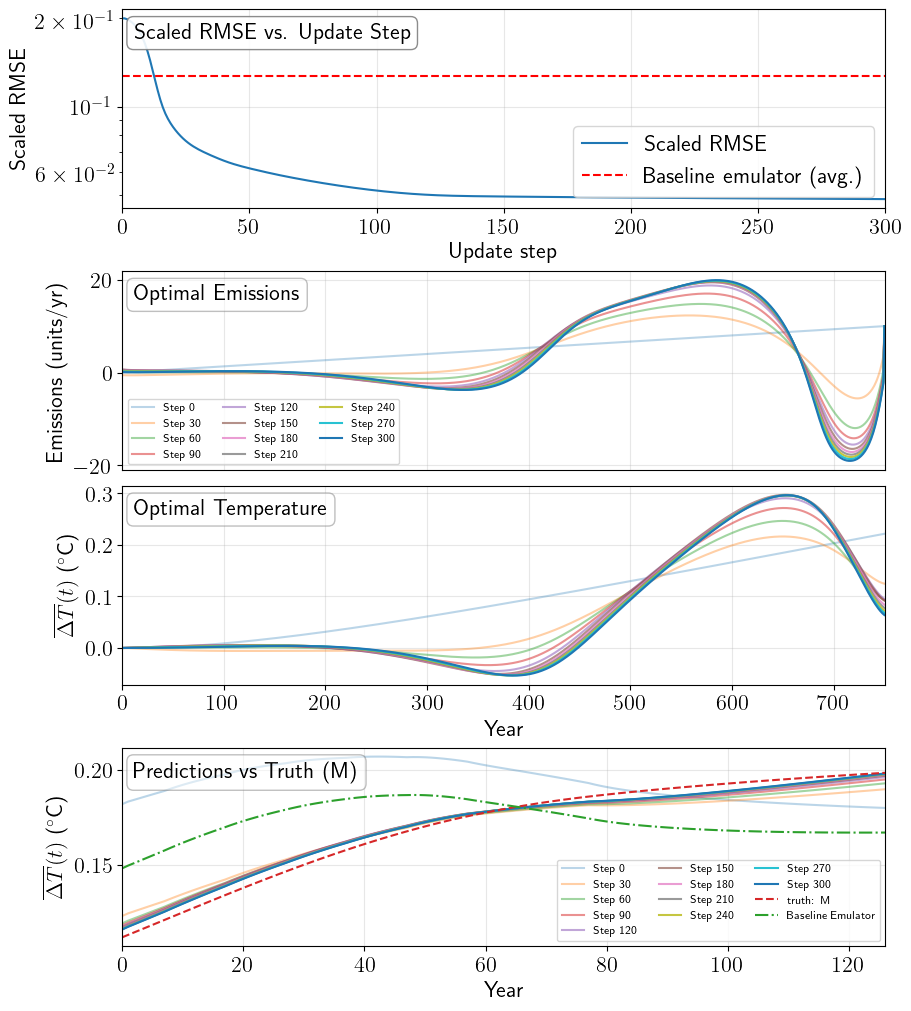

In [62]:
predict_plot = 'M'
utils_inverse.plot_inverse_results(
    results_N2O_tier1_ramp,
    baseline_results['Tier 1']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

In [64]:
emis_dict_valid = emis_dict_tier1_JAX.copy()
IC = 'gaussian'

results_N2O_tier1_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_tier1_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
    n_nonneg_prefix=0,
)

Found 300 updates in checkpoint, starting from here...


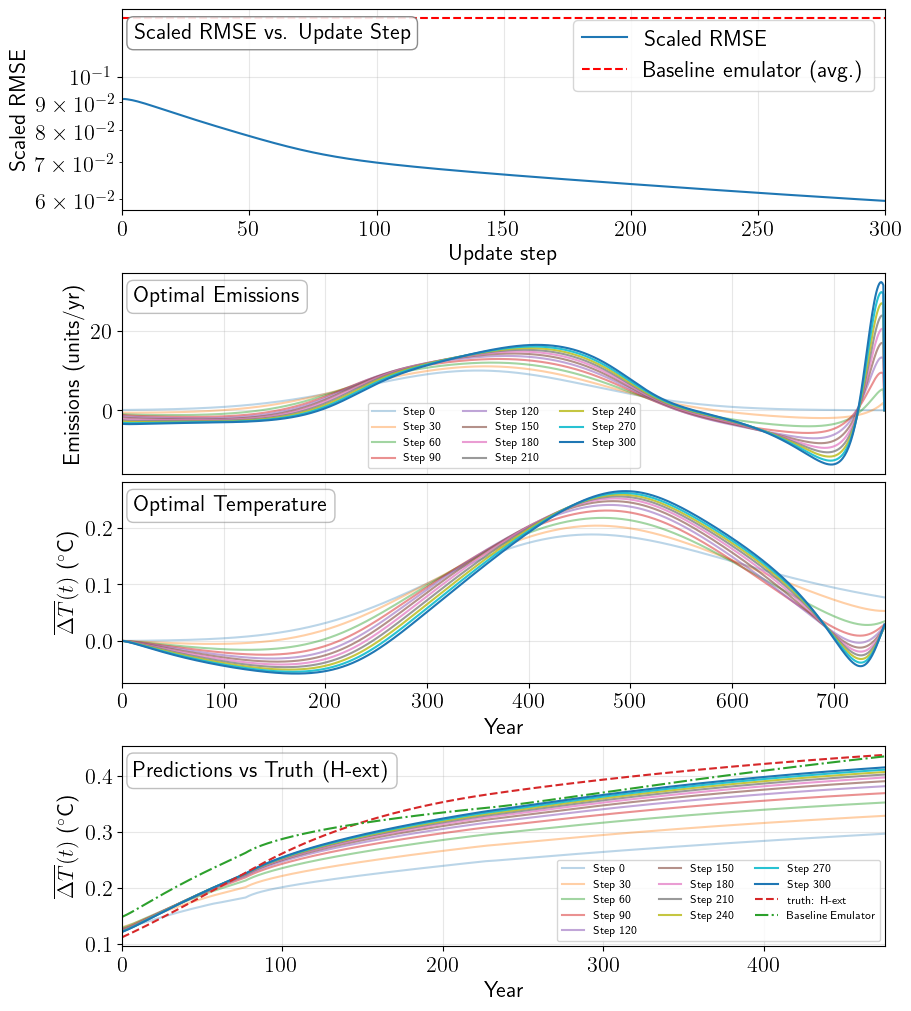

In [65]:
predict_plot = 'H-ext'
utils_inverse.plot_inverse_results(
    results_N2O_tier1_gaussian,
    baseline_results['Tier 1']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

### 2d. Optimize training data for predictive skill over ScenarioMIP tier 2, starting from constant, ramp, and Gaussian ICs

In [66]:
emis_dict_valid = emis_dict_tier2_JAX.copy()
IC = 'constant'

results_N2O_tier2_constant = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_tier2_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


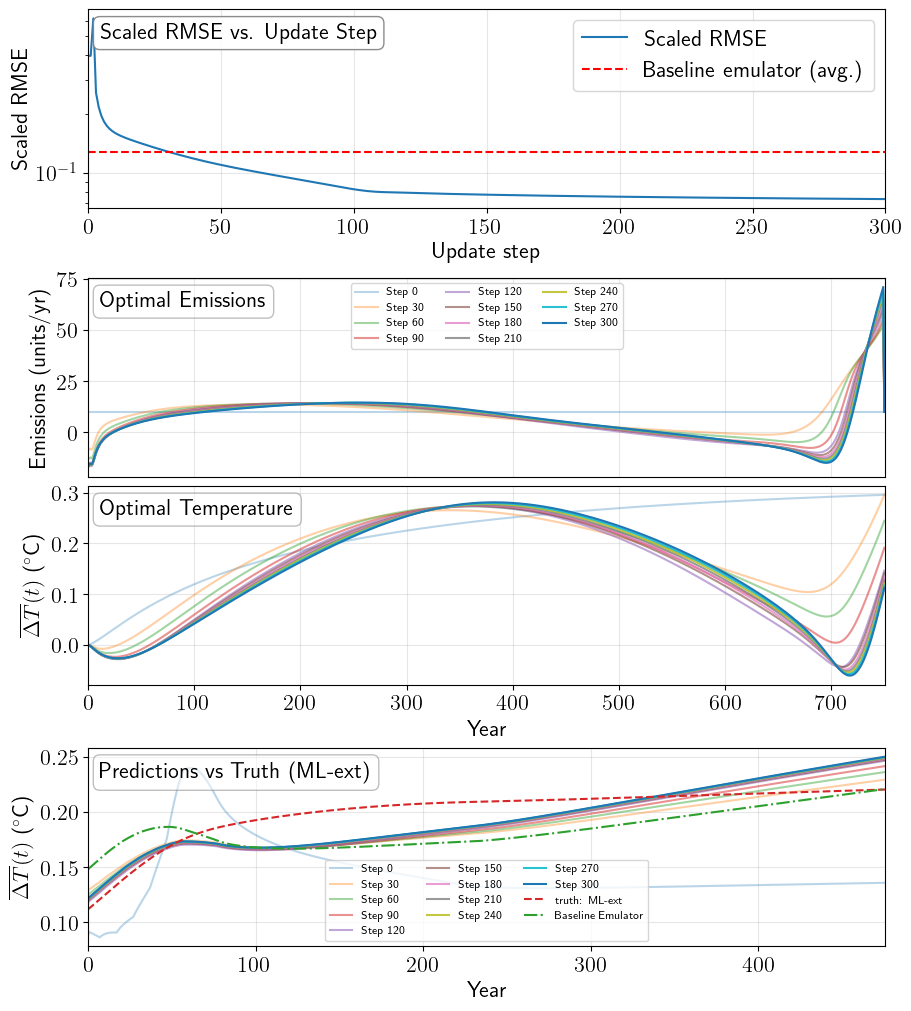

In [68]:
predict_plot = 'ML-ext'
utils_inverse.plot_inverse_results(
    results_N2O_tier2_constant,
    baseline_results['Tier 2']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 2'][predict_plot]
)

In [69]:
emis_dict_valid = emis_dict_tier2_JAX.copy()
IC = 'ramp'

results_N2O_tier2_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_tier2_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


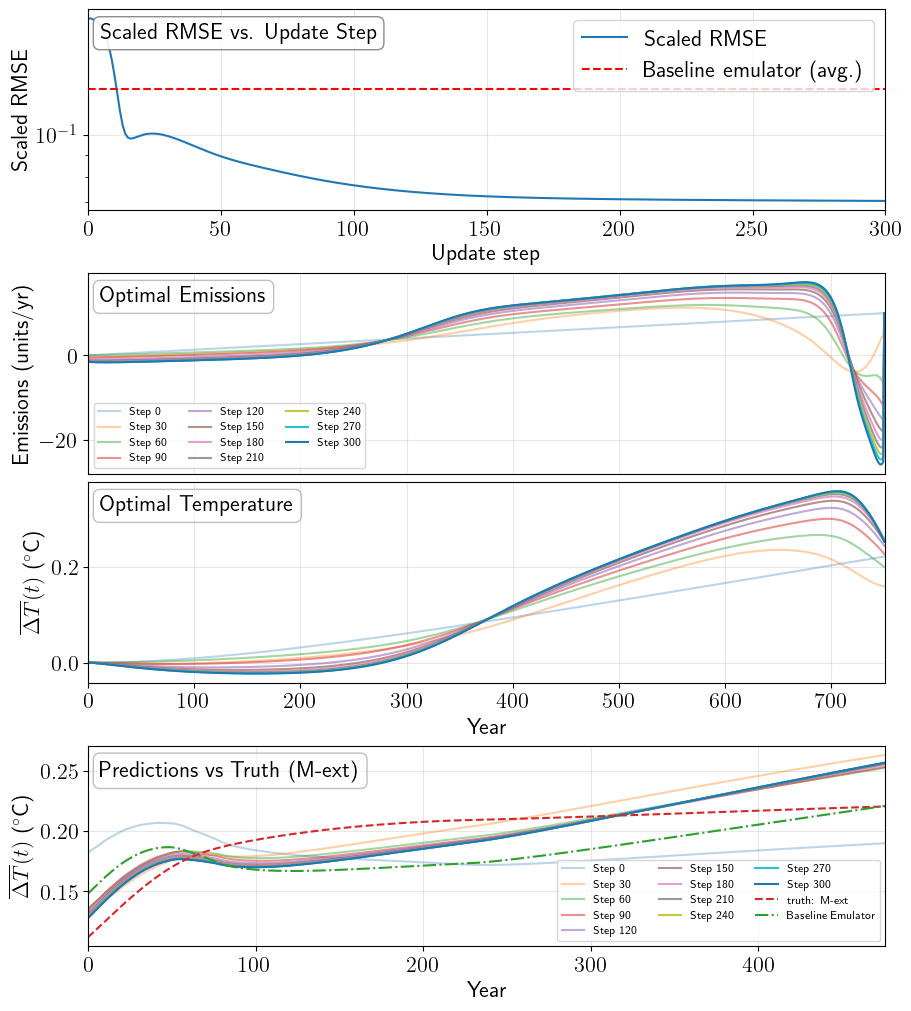

In [70]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_N2O_tier2_ramp,
    baseline_results['Tier 2']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 2'][predict_plot]
)

In [71]:
emis_dict_valid = emis_dict_tier2_JAX.copy()
IC = 'gaussian'

results_N2O_tier2_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_tier2_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


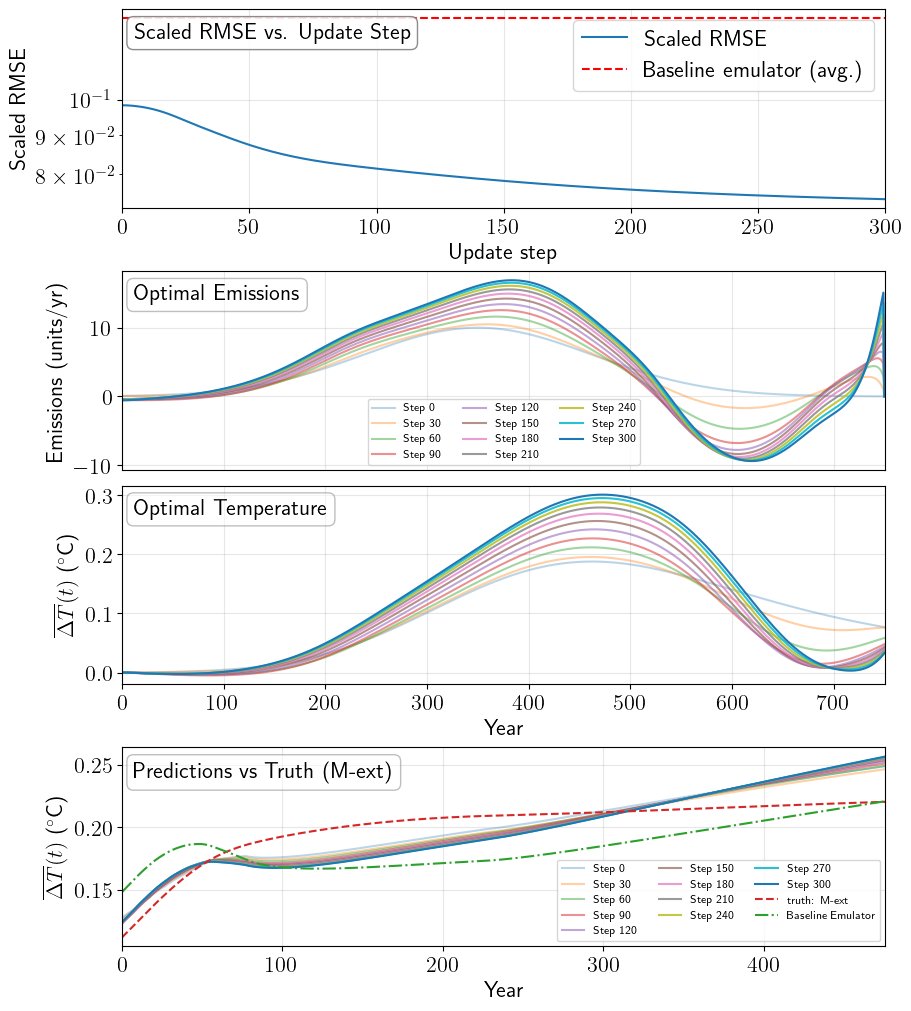

In [72]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_N2O_tier2_gaussian,
    baseline_results['Tier 2']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 2'][predict_plot]
)

### 2e. Optimize training data for predictive skill over DECK, starting from constant, ramp, and Gaussian ICs

In [73]:
emis_dict_valid = emis_dict_DECK_JAX.copy()
IC = 'constant'

results_N2O_DECK_constant = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_DECK_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


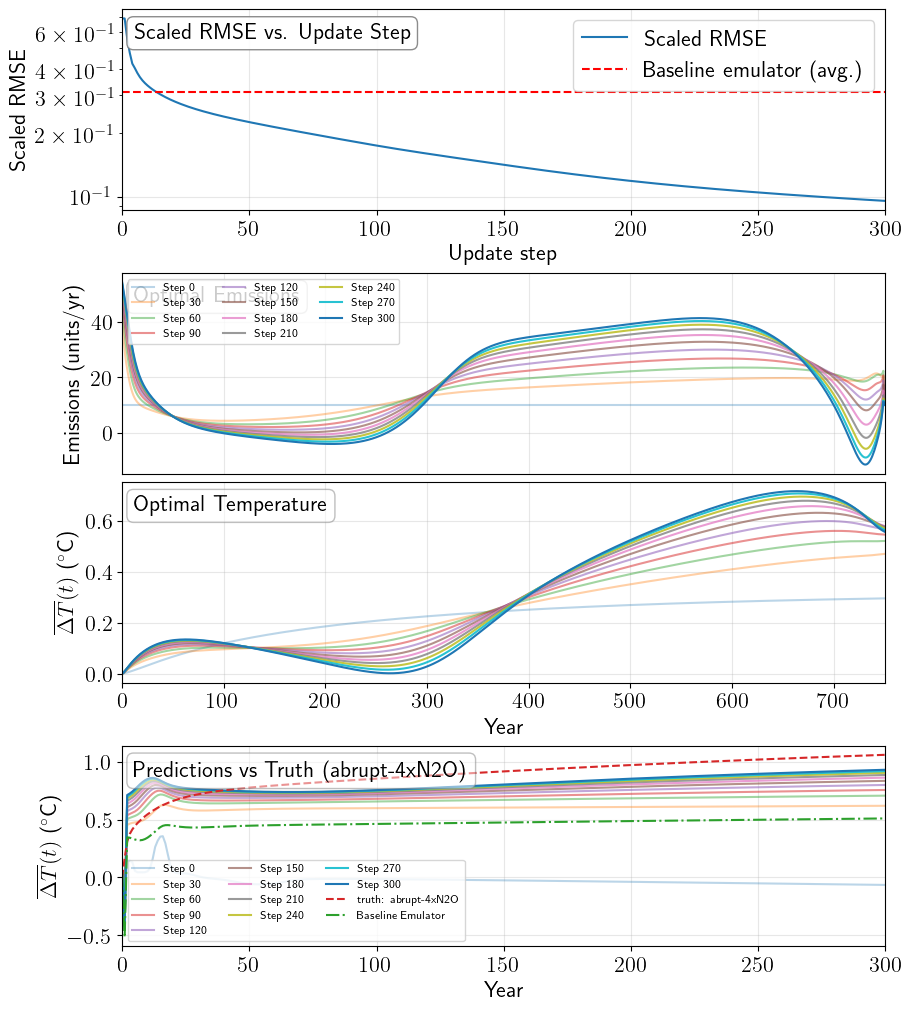

In [75]:
predict_plot = 'abrupt-4xN2O'
utils_inverse.plot_inverse_results(
    results_N2O_DECK_constant,
    baseline_results['DECK']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['DECK'][predict_plot]
)

In [80]:
emis_dict_valid = emis_dict_DECK_JAX.copy()
IC = 'ramp'

results_N2O_DECK_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_DECK_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


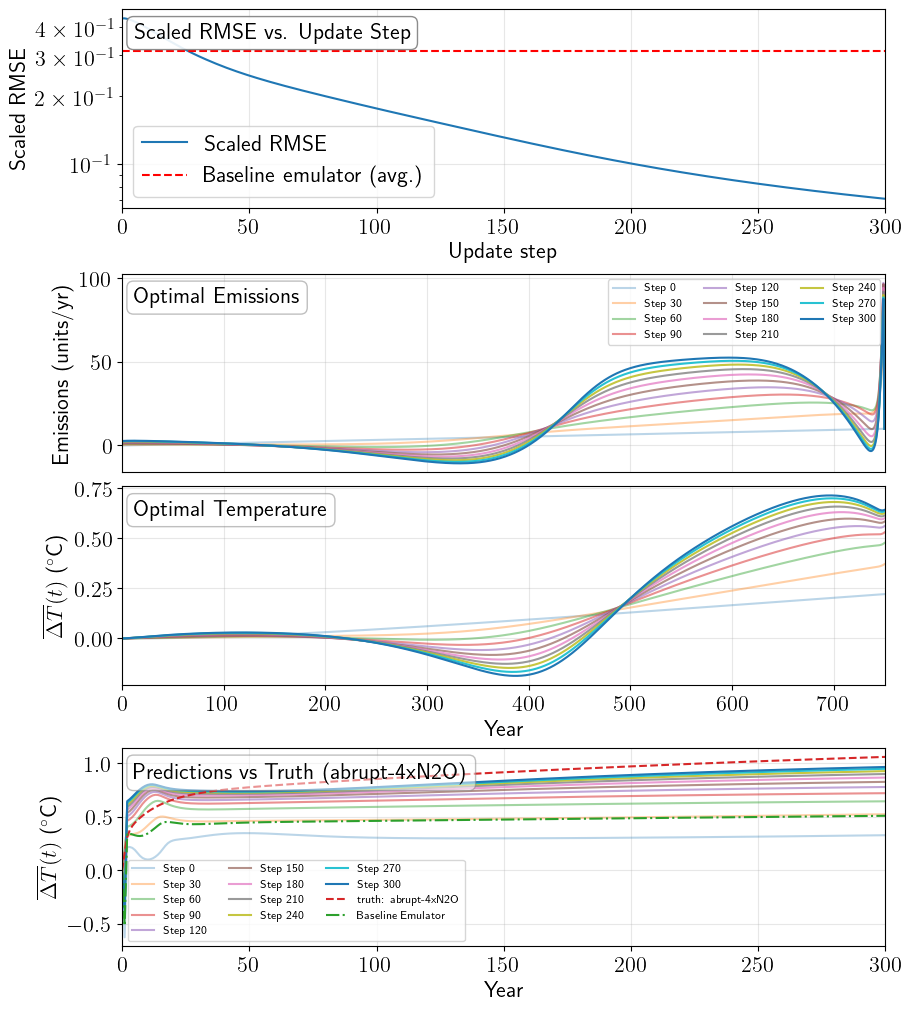

In [81]:
predict_plot = 'abrupt-4xN2O'
utils_inverse.plot_inverse_results(
    results_N2O_DECK_ramp,
    baseline_results['DECK']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['DECK'][predict_plot]
)

In [82]:
emis_dict_valid = emis_dict_DECK_JAX.copy()
IC = 'gaussian'

results_N2O_DECK_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_DECK_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


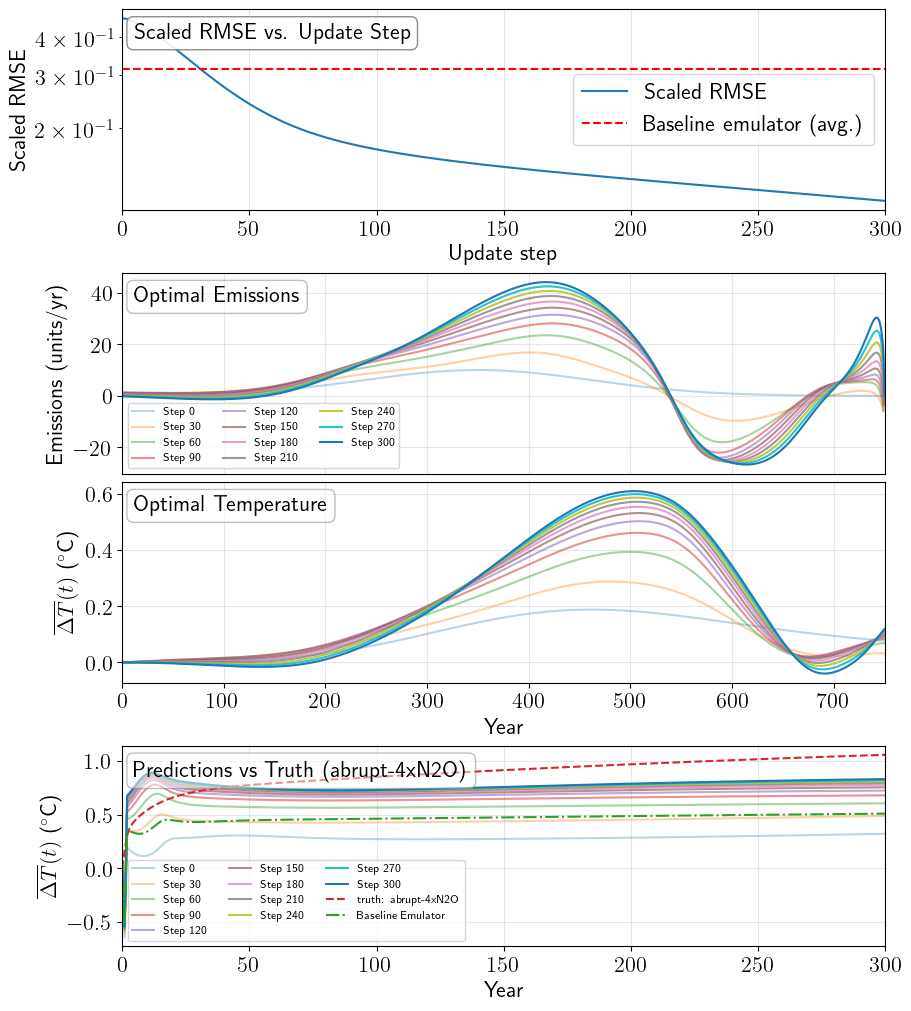

In [83]:
predict_plot = 'abrupt-4xN2O'
utils_inverse.plot_inverse_results(
    results_N2O_DECK_gaussian,
    baseline_results['DECK']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['DECK'][predict_plot]
)

### 2f. Optimize training data for predictive skill over all scenarios, starting from constant, ramp, and Gaussian ICs

In [84]:
emis_dict_valid = emis_dict_calib_JAX.copy()
IC = 'constant'

results_N2O_all_constant = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_all_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


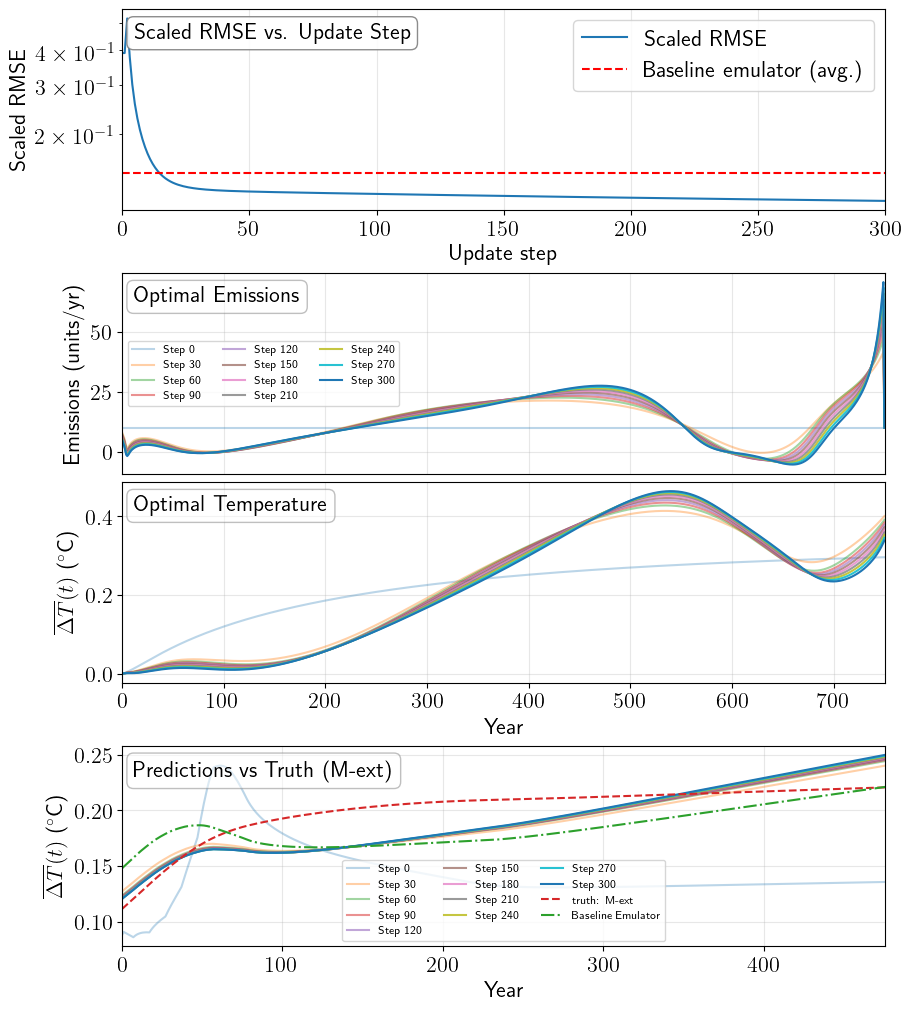

In [85]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_N2O_all_constant,
    baseline_results['All']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['All'][predict_plot]
)

In [86]:
emis_dict_valid = emis_dict_calib_JAX.copy()
IC = 'ramp'

results_N2O_all_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_all_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


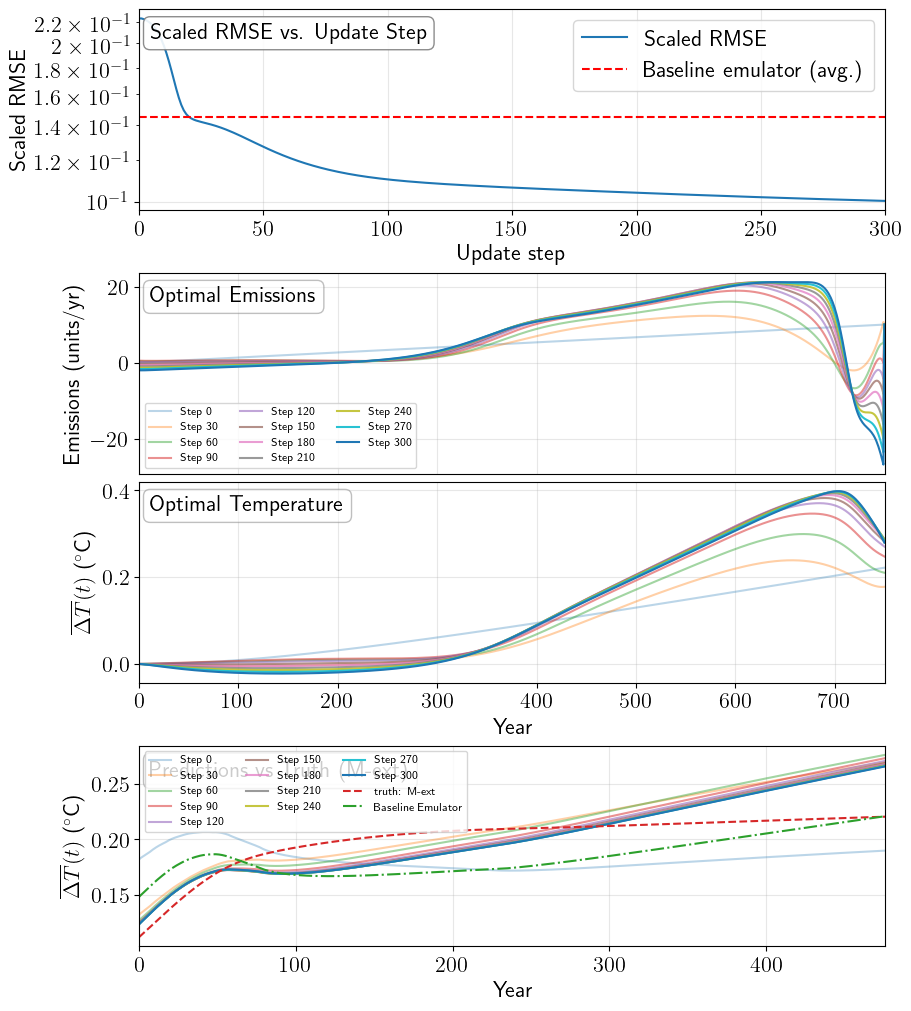

In [87]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_N2O_all_ramp,
    baseline_results['All']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['All'][predict_plot]
)

In [88]:
emis_dict_valid = emis_dict_calib_JAX.copy()
IC = 'gaussian'

results_N2O_all_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=300,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/n2o/inverse_{IC}_all_n2o_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("N2O",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 300 updates in checkpoint, starting from here...


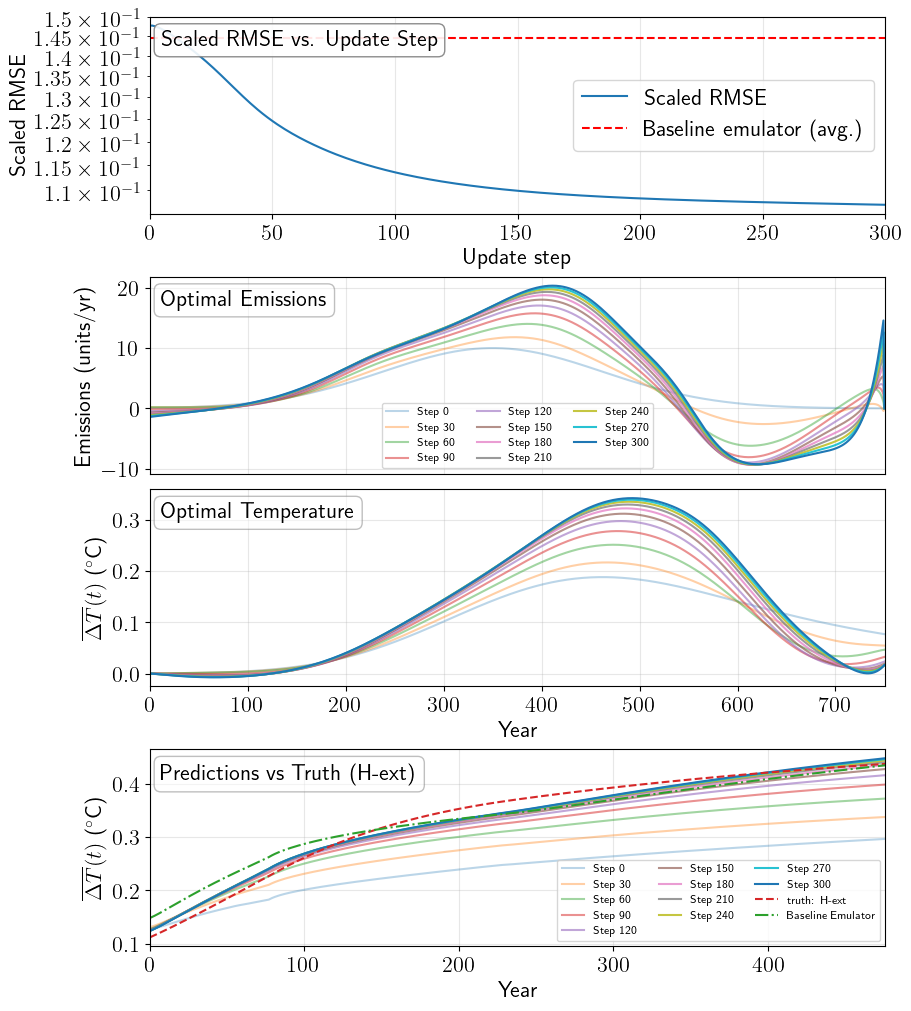

In [90]:
predict_plot = 'H-ext'
utils_inverse.plot_inverse_results(
    results_N2O_all_gaussian,
    baseline_results['All']['mean'],
    active_agents=('N2O',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['All'][predict_plot]
)